# Strava Analyzer Starter Notebook
Run ingest/catalog/context pipeline, then analyze structured commute patterns.

In [1]:
from pathlib import Path

import pandas as pd
pd.set_option("display.max_columns", None)  # optional


import strava_analyzer
from strava_analyzer.ingest import ingest_export
from strava_analyzer.query import (
    commute_counts_by_year,
    commute_route_selection,
    commute_speed_by_period,
    connect,
    filter_structured_commutes,
    filter_activities,
)

In [2]:
ingest_export(account_export_dir=Path("../account_export").resolve())

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,route_file,name_category,time_of_day_label,name_tag,is_structured_commute,commute_week_label,commute_week_number,commute_number,commute_period,commute_direction,commute_label_raw,commute_label_key,commute_parse_notes,equipment_type,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,960245903,2017-04-25 15:20:00,Daily Commute,Ride,8.04,4800,4800.0,NaN,15.2,NaN,NaN,general,None,Daily Commute,False,None,NaN,NaN,None,None,None,None,None,unknown,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,970619226,2017-05-04 13:52:01,Morning Commute,Ride,5.66,1003,945.0,NaN,14.9,NaN,activities/970619226.gpx,general,None,Morning Commute,False,None,NaN,NaN,None,None,None,None,None,unknown,868,43.087719,-89.369353,43.074103,-89.404880,43.064364,43.088004,-89.404880,-89.367060,"43.08772,-89.36935 | 43.06905,-89.38373 | 43.0..."
2,971322621,2017-05-04 23:09:31,Evening Run,Run,0.00,0,0.0,NaN,0.0,NaN,activities/971322621.gpx,general,None,Evening Run,False,None,NaN,NaN,None,None,None,None,None,unknown,1,43.073444,-89.404698,43.073444,-89.404698,43.073444,43.073444,-89.404698,-89.404698,"43.07344,-89.40470"
3,971341632,2017-05-04 23:09:47,Evening Ride,Ride,5.77,1231,1098.0,NaN,0.0,NaN,activities/971341632.gpx,general,None,Evening Ride,False,None,NaN,NaN,None,None,None,None,None,unknown,890,43.073345,-89.404443,43.087805,-89.369063,43.064266,43.087979,-89.404443,-89.368726,"43.07335,-89.40444 | 43.07066,-89.38104 | 43.0..."
4,976833978,2017-05-05 13:58:28,Morning Ride,Ride,6.95,29755,1548.0,NaN,30.9,NaN,activities/976833978.gpx,general,None,Morning Ride,False,None,NaN,NaN,None,None,None,None,None,unknown,1041,43.087557,-89.368853,43.087777,-89.369162,43.072794,43.088177,-89.405309,-89.368853,"43.08756,-89.36885 | 43.07289,-89.39791 | 43.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,17766728970,2026-03-18 12:50:30,Morning Ride,Ride,13.28,3205,2271.0,5.849,74.9,FX,activities/17766728970.gpx,general,None,Morning Ride,False,None,NaN,NaN,None,None,None,None,None,bike,2228,43.085267,-89.362529,43.021987,-89.466110,43.021545,43.085543,-89.466518,-89.362499,"43.08527,-89.36253 | 43.06586,-89.42091 | 43.0..."
858,17772326680,2026-03-18 21:12:37,Afternoon Ride,Ride,13.50,2326,1869.0,7.224,29.6,FX,activities/17772326680.gpx,general,None,Afternoon Ride,False,None,NaN,NaN,None,None,None,None,None,bike,1835,43.021746,-89.466086,43.085390,-89.362540,43.021494,43.085570,-89.466462,-89.361730,"43.02175,-89.46609 | 43.06696,-89.41639 | 43.0..."
859,17791020276,2026-03-20 12:02:50,Morning Ride,Ride,13.66,5201,2394.0,5.706,73.6,FX,activities/17791020276.gpx,general,None,Morning Ride,False,None,NaN,NaN,None,None,None,None,None,bike,2351,43.085442,-89.362518,43.021792,-89.466439,43.021685,43.085555,-89.466516,-89.362518,"43.08544,-89.36252 | 43.06360,-89.42534 | 43.0..."
860,17795946649,2026-03-20 20:49:27,Afternoon Ride,Ride,11.08,3882,1775.0,6.246,24.0,FX,activities/17795946649.gpx,general,None,Afternoon Ride,False,None,NaN,NaN,None,None,None,None,None,bike,1759,43.024386,-89.459805,43.050167,-89.395215,43.023293,43.050609,-89.459805,-89.387006,"43.02439,-89.45981 | 43.03542,-89.41362 | 43.0..."


In [3]:
con = connect()
commute_counts_by_year(con)

,year,commute_count
0,2024,226
1,2025,244
2,2026,1


In [4]:
commute_speed_by_period(con, year=2024)

,commute_period,avg_speed_mps,commute_count,avg_speed_kmh
0,am,6.754965,114,24.317874
1,pm,7.552045,112,27.187361


In [8]:
route_mix = commute_route_selection(con, year=2024)
route_mix

,route_label,commute_count


IndexError: index 0 is out of bounds for axis 0 with size 0

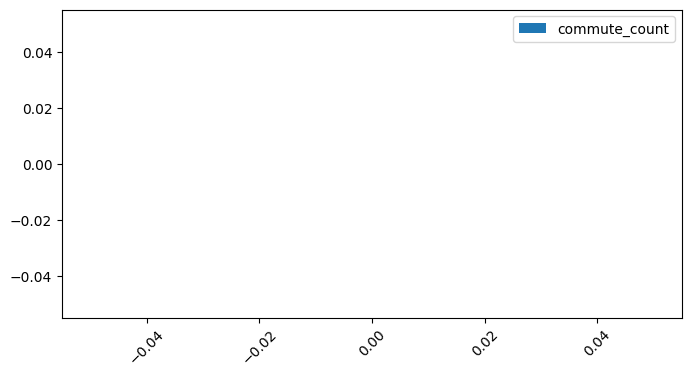

In [9]:
route_mix.plot.bar(x='route_label', y='commute_count', rot=45, figsize=(8,4))

In [11]:
filter_structured_commutes(con, year=2025).head()

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,...,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,13246547246,2025-01-02 13:45:22,Week 0.5 Commute 1 AM SW,Ride,13.11,2787,2012.0,6.520,73.3,FX,...,2220,43.084679,-89.363614,43.021971,-89.465903,43.021552,43.084679,-89.466512,-89.363587,"43.08468,-89.36361 | 43.06023,-89.42963 | 43.0..."
1,13250720968,2025-01-02 22:17:34,Week 0.5 Commute 2 PM Cannon,Ride,14.20,4006,1960.0,7.246,32.8,FX,...,1944,43.021673,-89.466588,43.085445,-89.362625,43.021547,43.085578,-89.466621,-89.361714,"43.02167,-89.46659 | 43.04124,-89.39445 | 43.0..."
2,13264911799,2025-01-03 13:24:00,Week 0.5 Commute 3 am sw,Ride,13.68,2103,2103.0,6.505,NaN,FX,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,13258960921,2025-01-03 22:28:46,Week 0.5 Commute 4 pm arb,Ride,13.23,1773,1708.0,7.751,55.2,FX,...,1697,43.021837,-89.465354,43.083840,-89.362787,43.021551,43.083840,-89.465535,-89.362682,"43.02184,-89.46535 | 43.05096,-89.41049 | 43.0..."
4,13281288689,2025-01-06 13:44:58,Week 1 Commute 5 am sw,Ride,13.30,2159,2011.0,6.618,71.6,FX,...,2006,43.085382,-89.362614,43.022782,-89.466109,43.021675,43.085555,-89.466402,-89.362561,"43.08538,-89.36261 | 43.06602,-89.42005 | 43.0..."


In [19]:
filter_activities(con)

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,...,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,17808990478,2026-03-21 21:00:53,Afternoon Ride,Ride,47.56,7328,6747.0,7.050,311.4,FX,...,6630,43.085395,-89.362626,43.085330,-89.362569,43.009123,43.094119,-89.461055,-89.315824,"43.08539,-89.36263 | 43.01775,-89.40348 | 43.0..."
1,17795946649,2026-03-20 20:49:27,Afternoon Ride,Ride,11.08,3882,1775.0,6.246,24.0,FX,...,1759,43.024386,-89.459805,43.050167,-89.395215,43.023293,43.050609,-89.459805,-89.387006,"43.02439,-89.45981 | 43.03542,-89.41362 | 43.0..."
2,17791020276,2026-03-20 12:02:50,Morning Ride,Ride,13.66,5201,2394.0,5.706,73.6,FX,...,2351,43.085442,-89.362518,43.021792,-89.466439,43.021685,43.085555,-89.466516,-89.362518,"43.08544,-89.36252 | 43.06360,-89.42534 | 43.0..."
3,17772326680,2026-03-18 21:12:37,Afternoon Ride,Ride,13.50,2326,1869.0,7.224,29.6,FX,...,1835,43.021746,-89.466086,43.085390,-89.362540,43.021494,43.085570,-89.466462,-89.361730,"43.02175,-89.46609 | 43.06696,-89.41639 | 43.0..."
4,17766728970,2026-03-18 12:50:30,Morning Ride,Ride,13.28,3205,2271.0,5.849,74.9,FX,...,2228,43.085267,-89.362529,43.021987,-89.466110,43.021545,43.085543,-89.466518,-89.362499,"43.08527,-89.36253 | 43.06586,-89.42091 | 43.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,976833978,2017-05-05 13:58:28,Morning Ride,Ride,6.95,29755,1548.0,NaN,30.9,None,...,1041,43.087557,-89.368853,43.087777,-89.369162,43.072794,43.088177,-89.405309,-89.368853,"43.08756,-89.36885 | 43.07289,-89.39791 | 43.0..."
858,971341632,2017-05-04 23:09:47,Evening Ride,Ride,5.77,1231,1098.0,NaN,0.0,None,...,890,43.073345,-89.404443,43.087805,-89.369063,43.064266,43.087979,-89.404443,-89.368726,"43.07335,-89.40444 | 43.07066,-89.38104 | 43.0..."
859,971322621,2017-05-04 23:09:31,Evening Run,Run,0.00,0,0.0,NaN,0.0,None,...,1,43.073444,-89.404698,43.073444,-89.404698,43.073444,43.073444,-89.404698,-89.404698,"43.07344,-89.40470"
860,970619226,2017-05-04 13:52:01,Morning Commute,Ride,5.66,1003,945.0,NaN,14.9,None,...,868,43.087719,-89.369353,43.074103,-89.404880,43.064364,43.088004,-89.404880,-89.367060,"43.08772,-89.36935 | 43.06905,-89.38373 | 43.0..."


In [24]:
activities_2024 = con.execute(
    """
    SELECT *
    FROM activities
    WHERE EXTRACT(year FROM activity_datetime) = 2024
    ORDER BY activity_datetime
    """
).fetch_df()
activities_2024 

,activity_id,activity_datetime,activity_name,activity_type,distance_m,elapsed_time_s,moving_time_s,average_speed_mps,elevation_gain_m,equipment_name,...,route_point_count,route_start_lat,route_start_lon,route_end_lat,route_end_lon,route_bbox_min_lat,route_bbox_max_lat,route_bbox_min_lon,route_bbox_max_lon,route_polyline_hint
0,10518042018,2024-01-08 13:57:31,Commute 7 (AM / Week 2 / Cannonball),Ride,13.46,2049,1914.0,7.036,61.3,FX,...,1910,43.084204,-89.365135,43.021929,-89.466375,43.021661,43.084204,-89.466378,-89.363640,"43.08420,-89.36513 | 43.04680,-89.40272 | 43.0..."
1,10521043682,2024-01-08 22:40:08,Commute 8 (PM / Week 2 / SW),Ride,13.41,2091,1894.0,7.084,29.7,FX,...,1888,43.021977,-89.466030,43.085364,-89.362543,43.021531,43.085591,-89.466655,-89.361766,"43.02198,-89.46603 | 43.06743,-89.41457 | 43.0..."
2,10524569487,2024-01-09 13:43:49,Commute 9 (Week 2 / AM / Arb),Ride,13.52,2890,2006.0,6.743,103.9,FX,...,1998,43.084115,-89.364457,43.021926,-89.466437,43.021610,43.084260,-89.466477,-89.363595,"43.08411,-89.36446 | 43.04917,-89.41820 | 43.0..."
3,10527561025,2024-01-09 22:00:05,Commute 10 (Week 2 / PM / SW / Blizzard!),Ride,13.39,2868,2403.0,5.575,35.9,FX,...,2397,43.022003,-89.466203,43.085453,-89.362644,43.021566,43.085583,-89.466641,-89.361800,"43.02200,-89.46620 | 43.06469,-89.42402 | 43.0..."
4,10537530134,2024-01-11 13:37:01,Commute 11 (Week 2 / AM / SW / Uncleared snow ...,Ride,13.12,2613,2492.0,5.268,72.8,FX,...,2475,43.084166,-89.364626,43.022003,-89.466462,43.021596,43.084193,-89.466512,-89.363570,"43.08417,-89.36463 | 43.05812,-89.43318 | 43.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,13234368330,2024-12-28 21:48:29,Skiing but without skis so trail running,Run,4.97,2102,1954.0,2.544,135.1,None,...,2094,46.019928,-88.890850,46.019697,-88.891269,46.014824,46.023845,-88.903002,-88.890223,"46.01993,-88.89085 | 46.02079,-88.90153 | 46.0..."
289,13234368318,2024-12-29 17:28:37,Elvoy Springs Hike,Hike,2.33,2176,1840.0,1.271,36.7,None,...,2167,46.007454,-88.902717,46.006929,-88.904003,46.006917,46.014712,-88.906943,-88.901330,"46.00745,-88.90272 | 46.01467,-88.90694 | 46.0..."
290,13234368386,2024-12-29 21:25:30,Rivers Reach Trail Run,Run,4.90,3079,1956.0,2.507,98.9,None,...,3078,46.020003,-88.891100,46.019965,-88.890900,46.019949,46.031887,-88.892021,-88.881511,"46.02000,-88.89110 | 46.02432,-88.88555 | 46.0..."
291,13234368401,2024-12-30 18:25:19,Anvil Military Trailhead Lake Loop,Hike,5.55,4580,4262.0,1.304,84.8,None,...,4581,45.919345,-89.065806,45.919438,-89.068755,45.906802,45.919869,-89.068838,-89.058030,"45.91934,-89.06581 | 45.90910,-89.06064 | 45.9..."
